# Exploring the OpenAI's Software research results

In [1]:
import pandas as pd

In [2]:
from collections import Counter

In [3]:
import pymongo

In [4]:
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["mydatabase"]

In [5]:
ai_assistant_research_docs = db['research_results']

In [6]:
# mongodb example: use a regex to find case-insensitively
# results = ai_assistant_research_docs.find( {'name': {'$regex': '^geospatial$', '$options': 'i'}}, {} )

In [7]:
# mongodb example: use a compound find condition
# results = ai_assistant_research_docs.find(
#     {
#         'and': [
#             {'name': 'geospatial'},
#             {'archived': False}
#         ]
#     }, {} )
#results = ai_assistant_research_docs.find( {'name': 'geospatial', 'owner.login': 'opengeos'},  )
#results = ai_assistant_research_docs.find( {'name': 'geospatial', 'archived': False},  )
#results = ai_assistant_research_docs.find( {'name': 'geospatial', 'forks_count': 282},  )

In [8]:
results = ai_assistant_research_docs.find({},{})

In [9]:
results = list( results )

In [10]:
len( results )

1000

In [11]:
results_df = pd.DataFrame( results )

In [12]:
results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 90 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   _id                          1000 non-null   object 
 1   id                           1000 non-null   int64  
 2   node_id                      1000 non-null   object 
 3   name                         1000 non-null   object 
 4   full_name                    1000 non-null   object 
 5   private                      1000 non-null   bool   
 6   owner_login                  1000 non-null   object 
 7   html_url                     1000 non-null   object 
 8   description                  1000 non-null   object 
 9   fork                         1000 non-null   bool   
 10  url                          1000 non-null   object 
 11  forks_url                    1000 non-null   object 
 12  keys_url                     1000 non-null   object 
 13  collaborators_url  

# ChatGPT-provided keywords

In [13]:
successful_results = [ _ for _ in results if 'keywords' in _ ]

In [14]:
chat_gpt_keywords = [ i for o in successful_results for i in o['keywords'] ]

In [15]:
c = Counter( chat_gpt_keywords )

In [16]:
c.most_common()[:30]

[('geospatial', 605),
 ('GIS', 475),
 ('mapping', 302),
 ('data visualization', 253),
 ('spatial analysis', 247),
 ('data analysis', 239),
 ('visualization', 185),
 ('spatial data', 180),
 ('Python', 168),
 ('data processing', 153),
 ('geographic information', 136),
 ('data management', 107),
 ('open data', 100),
 ('machine learning', 89),
 ('data science', 86),
 ('remote sensing', 73),
 ('geospatial analysis', 73),
 ('education', 70),
 ('resources', 69),
 ('data manipulation', 61),
 ('analytics', 58),
 ('tutorials', 56),
 ('geographic data', 54),
 ('geodata', 53),
 ('data integration', 53),
 ('open-source', 52),
 ('satellite imagery', 51),
 ('JavaScript', 51),
 ('API', 48),
 ('environmental monitoring', 46)]

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

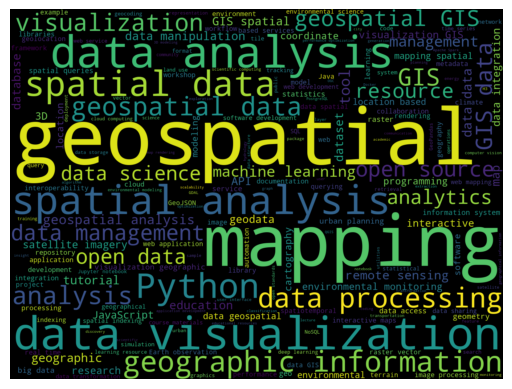

In [18]:
wordcloud = WordCloud(width=1600, height=1200, margin=0).generate( " ".join( chat_gpt_keywords ) )

# Display the generated image:
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.margins(x=0, y=0)
plt.show()

In [19]:
successful_results = [ _ for _ in results if 'commercial_comps' in _ ]
commercial_comps = [ i for o in successful_results for i in o['commercial_comps'] ]

In [20]:
c = Counter( commercial_comps )

In [21]:
c.most_common()[30:]

[('Azure Cosmos DB', 10),
 ('Microsoft Azure Machine Learning', 10),
 ('Azure Data Factory', 10),
 ('HERE Technologies', 10),
 ('AWS Data Exchange', 9),
 ('Google Cloud Functions', 9),
 ('Hexagon Geospatial', 9),
 ('Google Earth', 9),
 ('Google AI Platform', 8),
 ('PlanetScope', 8),
 ('Mapbox Studio', 8),
 ('CesiumJS', 7),
 ('Safe Software FME', 7),
 ('DataRobot', 7),
 ('Azure Functions', 7),
 ('Google BigQuery GIS', 7),
 ('ESRI ArcGIS Online', 7),
 ('Microsoft Azure Cosmos DB', 6),
 ('Looker', 6),
 ('Azure Cognitive Search', 6),
 ('Esri ArcGIS Pro', 6),
 ('Autodesk InfraWorks', 6),
 ('Power BI', 6),
 ('Google Cloud Bigtable', 6),
 ('Leaflet', 6),
 ('Mapbox GL JS', 6),
 ('QlikView', 6),
 ('ERDAS IMAGINE', 6),
 ('SAS', 6),
 ('HERE Location Services', 5),
 ('Google Cloud Search', 5),
 ('Google Data Studio', 5),
 ('Mapbox Geocoding API', 5),
 ('Qlik Sense', 5),
 ('Google Cloud BigQuery GIS', 5),
 ('Amazon DynamoDB', 5),
 ('Esri', 5),
 ('AWS Glue', 5),
 ('HERE Maps', 5),
 ('Esri CityEngine

In [22]:
successful_results = [ _ for _ in results if 'open_source_comps' in _ ]
os_comps = [ i.lower() for o in successful_results for i in o['open_source_comps'] ]

In [23]:
c = Counter( os_comps )

In [24]:
c.most_common()[:30]

[('geoserver', 224),
 ('postgis', 203),
 ('geopandas', 198),
 ('qgis', 181),
 ('gdal', 175),
 ('leaflet', 134),
 ('openlayers', 104),
 ('rasterio', 85),
 ('shapely', 50),
 ('openstreetmap', 43),
 ('mapserver', 38),
 ('grass gis', 34),
 ('geotools', 31),
 ('scikit-learn', 31),
 ('folium', 27),
 ('tensorflow', 27),
 ('fiona', 21),
 ('cesiumjs', 21),
 ('pandas', 20),
 ('geodjango', 19),
 ('pyproj', 19),
 ('matplotlib', 17),
 ('maplibre', 17),
 ('opencv', 17),
 ('geonode', 16),
 ('kepler.gl', 15),
 ('deck.gl', 14),
 ('plotly', 13),
 ('qgis server', 12),
 ('numpy', 12)]

# OpenAI API call average time per call

<Axes: ylabel='Frequency'>

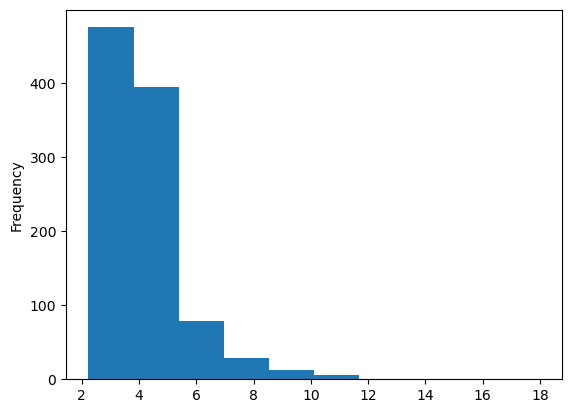

In [25]:
results_df['time'].plot.hist( bins=10 )

In [26]:
print( f'Full run took { results_df['time'].sum() / 60 :0.1f} minutes.' )

Full run took 73.6 minutes.


# Is the repo actually geospatial related?

In [27]:
results_df['is_geospatial_software'].value_counts()

is_geospatial_software
True     703
False    297
Name: count, dtype: int64

## Non geospatial repos

In [28]:
results_df.loc[ results_df['is_geospatial_software'] == False, 'full_name'].head(30)

7                                    sshuair/awesome-gis
8                           sacridini/Awesome-Geospatial
29            acgeospatial/awesome-earthobservation-code
33                 jorisvandenbossche/geopandas-tutorial
34           softwareunderground/awesome-open-geoscience
36     PacktPublishing/Learning-Geospatial-Analysis-w...
44                  chrieke/awesome-geospatial-companies
45                     aikho/awesome-feature-engineering
46                TrainingByPackt/SQL-for-Data-Analytics
51                               aws/studio-lab-examples
55                                             antvis/L7
57                                 RediSearch/RediSearch
59                                 RadarCODE/awesome-sar
61     Azure-Samples/serverless-full-stack-apps-azure...
63                                       apache/superset
75     PacktPublishing/Mastering-Geospatial-Analysis-...
76                         googlecreativelab/balloon-pop
79         mdiener21/python-geo

## Most popular geospatial repos

In [30]:
wanted_cols = ['full_name', 'stargazers_count', 'description' ] 

In [31]:
pd.set_option( 'display.max_colwidth', 120 )

In [32]:
results_df.loc[ results_df['is_geospatial_software'] == True, wanted_cols ].sort_values( 'stargazers_count', ascending=False ).head(30)

,full_name,stargazers_count,description
10,qgis/QGIS,10312,"QGIS is a desktop geographic information system that allows users to create, edit, visualize, and analyze geospatial..."
77,keplergl/kepler.gl,10245,"Kepler.gl is a powerful visualization tool that allows users to create interactive, geospatial maps using large data..."
31,Turfjs/turf,9191,Turf is a JavaScript library designed for spatial analysis of geographic data. It provides various geospatial functi...
15,tidwall/tile38,9049,"Tile38 is a geospatial database that enables users to store, manage, and query spatial data. It allows for the handl..."
72,alexreisner/geocoder,6336,Geocoder is a software package that enables users to convert addresses into geographic coordinates (latitude and lon...
49,gboeing/osmnx,4821,"Osmnx is a Python library that enables users to acquire, model, visualize, and analyze street networks and other geo..."
19,uber/h3,4805,H3 is a spatial indexing system that allows users to encode geographic locations into an index structure that works ...
9,OSGeo/gdal,4770,GDAL (Geospatial Data Abstraction Library) is a translator library for raster and vector geospatial data formats. It...
307,geopandas/geopandas,4428,GeoPandas is a Python library that extends the capabilities of pandas to support spatial data operations. It allows ...
4,geoserver/geoserver,3777,"GeoServer is a software server that facilitates the sharing, processing, and editing of geospatial data. It allows u..."


In [33]:
'leaflet.js' in list( results_df['name'].str.lower() )

False

# How well is ChatGPT-4o-mini familiar with the given repo?

In [34]:
results_df['awareness'].value_counts()

awareness
True     907
False     93
Name: count, dtype: int64

In [35]:
results_df['confidence'].value_counts()

confidence
8    703
7    172
2     38
3     26
9     22
5     14
6     10
4      8
1      6
0      1
Name: count, dtype: int64